#### Project 5: Zips Law distribution of Finnish Wikipedia Corpus.

This project investigates various facets of the Zips law and how it can be empirically tested on a set of well known corpuses.

In [ ]:
import zipfile
import requests
from io import BytesIO
import os, re, spacy
import glob
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from pathlib import Path


In [ ]:
# download database zip, extract, create iterable of VRT file-names

url = "https://www.kielipankki.fi/download/wikipedia-fi/wikipedia-fi-2017-src/wikipedia-fi-2017-src.zip"

if not os.path.exists("wikipedia-fi-2017-src"):
    zipfile.ZipFile(BytesIO(requests.get(url).content)).extractall()

In [2]:
files = glob.glob("wikipedia-fi-2017-src/wikipedia-fi-2017-src/*.VRT")

In [3]:
files = glob.glob("wikipedia-fi-2017-src/*.VRT")

Database of "wiki_part**.VRT" files: Universal Dependencies–style vertical (VRT/CoNLL-U hybrid) files.

- Structural tags: \<doc\>, \<paragraph\>, \<sentence\>

- Token lines: ID, FORM, LEMMA, UPOS, XPOS, FEATS, HEAD, DEPREL, DEPS, MISC

Basically CoNLL-U tables wrapped in XML-like tags. \
https://universaldependencies.org/docs/format.html

In [4]:
# create dataframe of a VRT file
def parse_vrt_to_df(path: str) -> pd.DataFrame:
    rows = []
    doc_id = None
    sent_id = 0

    tag_re = re.compile(r"<(/)?(\w+)(.*?)>")
    attr_re = re.compile(r'(\w+)="(.*?)"')

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # deal with XML
            if line.startswith("<"):
                m = tag_re.match(line)
                if not m:
                    continue
                closing, tagname, attrs_str = m.groups()

                # add document counter
                if not closing and tagname == "doc":
                    attrs = dict(attr_re.findall(attrs_str))
                    doc_id = attrs.get("id", None)

                # add sentence counter
                elif not closing and tagname == "sentence":
                    sent_id += 1
                continue

            # deal with tokens
            parts = line.split("\t")
            if len(parts) < 10:
                continue
            token_id, form, lemma, upos, xpos, feats, head, deprel, deps, misc = parts[:10]
            rows.append({
                "doc_id": doc_id,
                "sent_id": sent_id,
                "token_id": int(token_id),
                "form": form,
                "lemma": lemma,
                "upos": upos,
                "xpos": xpos if xpos != "_" else None,
                "feats": feats if feats != "_" else None,
                "head": int(head) if head.isdigit() else None,
                "deprel": deprel,
                "deps": deps if deps != "_" else None,
                "misc": misc if misc != "_" else None,
            })

    df = pd.DataFrame(rows)
    return df


# create dataframe of all VRT files
def create_df(files) -> pd.DataFrame:
    dfs = []
    for f in tqdm(files):
        dfs.append(parse_vrt_to_df(f))
    return pd.concat(dfs, ignore_index=True)

In [ ]:
# takes a while (memory usage: 7.5+ GB)
df = create_df(files)

  0%|          | 0/66 [00:00<?, ?it/s]

100%|██████████| 66/66 [04:23<00:00,  3.99s/it]


In [ ]:
# save dataframe as parquet file (took ~25min XD)
df.to_parquet("merged_corpus.parquet", index=False)

In [3]:
# load dataframe from parquet file (</~1min)
df = pd.read_parquet("merged_corpus.parquet")

In [13]:
# Only load part of the PARQUET file because it used too much RAM for my google collab

import pandas as pd

cols = ["doc_id","sent_id", "token_id", "form","upos"]
df = pd.read_parquet("merged_corpus.parquet", columns=cols)

df.head()

,doc_id,sent_id,token_id,form,upos
0,1,1,1,Amsterdam,PROPN
1,1,2,1,Amsterdam,PROPN
2,1,2,2,on,VERB
3,1,2,3,Alankomaiden,PROPN
4,1,2,4,pääkaupunki,NOUN


In [5]:
# create linked entity set of a VRT file
def parse_vrt_to_set(path):
    linked_entities = set()
    # doc_id = None
    doc_title = None

    tag_re = re.compile(r"<(/)?(\w+)(.*?)>")
    attr_re = re.compile(r'(\w+)="(.*?)"')

    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # deal with XML
            if line.startswith("<"):
                m = tag_re.match(line)
                if not m:
                    continue
                closing, tagname, attrs_str = m.groups()

                # add document id and title
                if not closing and tagname == "doc":
                    attrs = dict(attr_re.findall(attrs_str))
                    # doc_id = attrs.get("id", None)
                    doc_title = attrs.get("title", None)
                    linked_entities.add(doc_title)
                continue

    return linked_entities


# create linked entity set of all VRT files
def create_set(files):
    all_linked_entities = set()
    for f in tqdm(files): 
        all_linked_entities = all_linked_entities.union(parse_vrt_to_set(f))
    return all_linked_entities

In [6]:
linked_entities = create_set(files)

100%|██████████| 66/66 [00:28<00:00,  2.28it/s]


In [7]:
# documents: 425506
print(f"Number of pages (distinct linked entities) in dataset: {len(linked_entities)}\n")

Number of pages (distinct linked entities) in dataset: 425506



In [ ]:
# series: doc_id -> linked entity count
# ~4min
counts = (
    df.assign(in_set=df["form"].isin(linked_entities))
      .groupby("doc_id")["in_set"]
      .sum()
)

In [9]:
counts.index = counts.index.astype(int)

if not os.path.isfile("linked_entities.txt"):
    with open("linked_entities.txt", "a") as f:
        for i, t in counts.sort_index().items():
            print(f"Number of linked entities in page of doc_id {i}: {t}", file=f) 

print("Output in linked_entities.txt")

Output in linked_entities.txt


In [10]:
# series: doc_id -> tokens count
vc = df['doc_id'].value_counts()
# counts per doc == tokens in doc
vc.index = vc.index.astype(int)
if not os.path.isfile("tokens.txt"):
    with open("tokens.txt", "a") as f:
        for v, c in vc.sort_index().items():
            print(f"Number of tokens in page of doc_id {v}: {c}", file=f) 

print("Output in tokens.txt")

Output in tokens.txt


Minimum Number of Tokens observed on a Page: 1
Maximum Number of Tokens observed on a Page: 32864


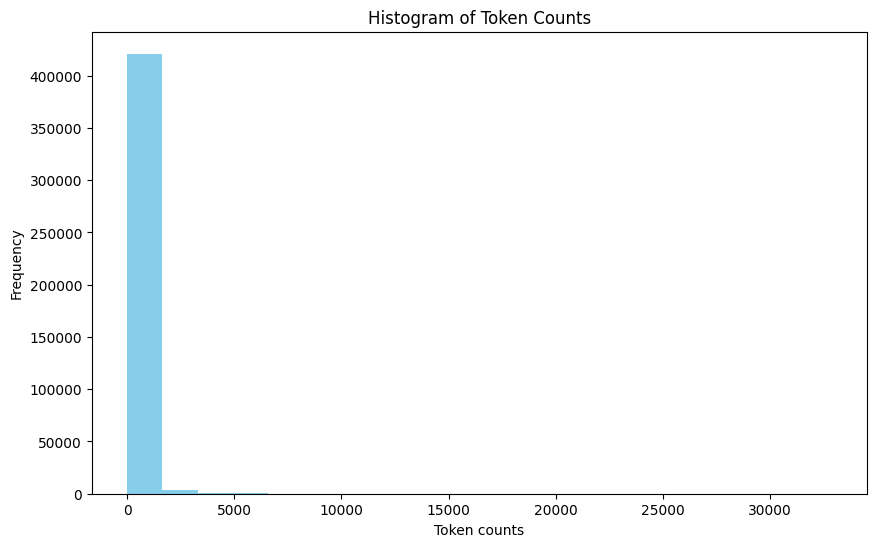

In [11]:
# min, max, and bins
min = vc.min()
max = vc.max()
print(f"Minimum Number of Tokens observed on a Page: {min}")
print(f"Maximum Number of Tokens observed on a Page: {max}")
bins = 20
edges = np.linspace(0, max, bins+1)
div = pd.cut(vc, bins=edges)
bin_counts = div.value_counts().sort_index()

freq = np.sort(bin_counts.values)[::-1]
ranks = np.arange(1, len(freq) + 1)

plt.figure(figsize=(10,6))
plt.hist(vc.values, color="skyblue", bins=20) # or plt.bar(ranks, freq, alpha=0.5)
plt.xlabel("Token counts")
plt.ylabel("Frequency")
plt.title("Histogram of Token Counts")
plt.show()

In [12]:
def fit_zipf(data, offset=False, title="Zipf\'s Law"):
    freq = np.sort(data)[::-1]
    # freq = freq[freq > 0]

    ranks = np.arange(1, len(freq) + 1)

    B = 0.1

    log_r = np.log10(ranks + B)
    if offset:
        log_L = np.log10(freq + 1) # baseline +1 to deal with 0 frequencies which would throw error
    else:
        log_L = np.log10(freq)

    slope, intercept, r, p, e = stats.linregress(log_r, log_L)
    alpha = -slope
    C = 10 ** intercept

    log_L_pred = intercept + slope * log_r

    n = len(log_r)
    t_val = stats.t.ppf(0.95, n - 2)
    s_yx = np.sqrt(np.sum((log_L - log_L_pred) ** 2) / (n - 2))
    mean_x = np.mean(log_r)
    conf = t_val * s_yx * np.sqrt(1/n + (log_r - mean_x)**2 / np.sum((log_r - mean_x)**2))

    upper = log_L_pred + conf
    lower = log_L_pred - conf

    r2 = r**2
    k = 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    plt.figure(figsize=(10,6))
    plt.scatter(log_r, log_L, s=10, alpha=0.5, label="Observed frequencies")
    plt.plot(log_r, log_L_pred, "r", label="Linear fit")
    plt.fill_between(log_r, lower, upper, color="pink", alpha=0.3, label="90% conf. interval")
    plt.xlabel("log10(rank + B)")
    plt.ylabel("log10(freq)")
    plt.title(title)
    plt.legend()
    plt.show()

    # print(f"C = {C}")
    # print(f"alpha = {alpha}")

    outside = np.sum((log_L < lower) | (log_L > upper))
    percent_outside = 100 * outside / len(log_L)
    print(f"Observations outside 90% confidence bounds: {percent_outside}%")

    print(f"\nR^2 = {r2}")
    print(f"adjusted R^2 = {adj_r2}")

    if adj_r2 > 0.9:
        print("\nFits Zipf\'s law very well.")
    elif adj_r2 > 0.7:
        print("\nFits Zipf\'s law roughly.")
    else:
        print("\nDoes not fit Zipf\'s law well.")

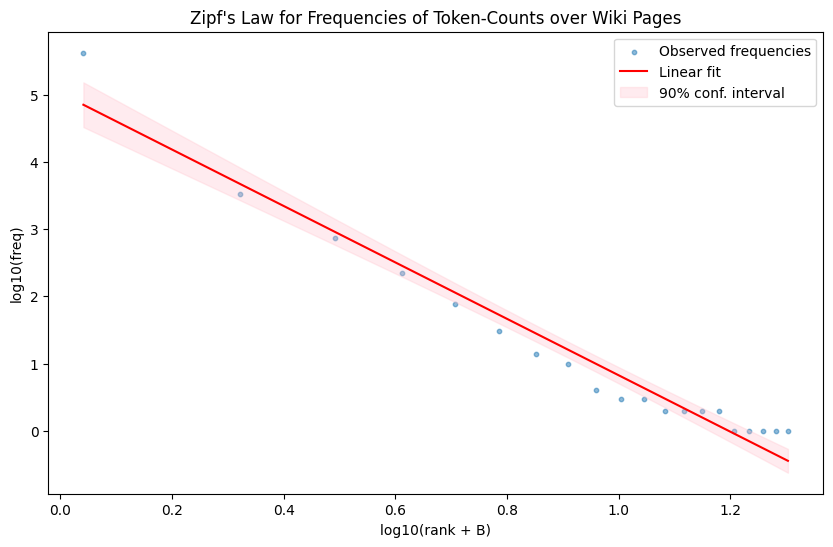

Observations outside 90% confidence bounds: 65.0%

R^2 = 0.9597822722885081
adjusted R^2 = 0.9575479540823141

Fits Zipf's law very well.


In [13]:
# zipf fitting
fit_zipf(bin_counts.values, offset=True, title="Zipf\'s Law for Frequencies of Token-Counts over Wiki Pages")

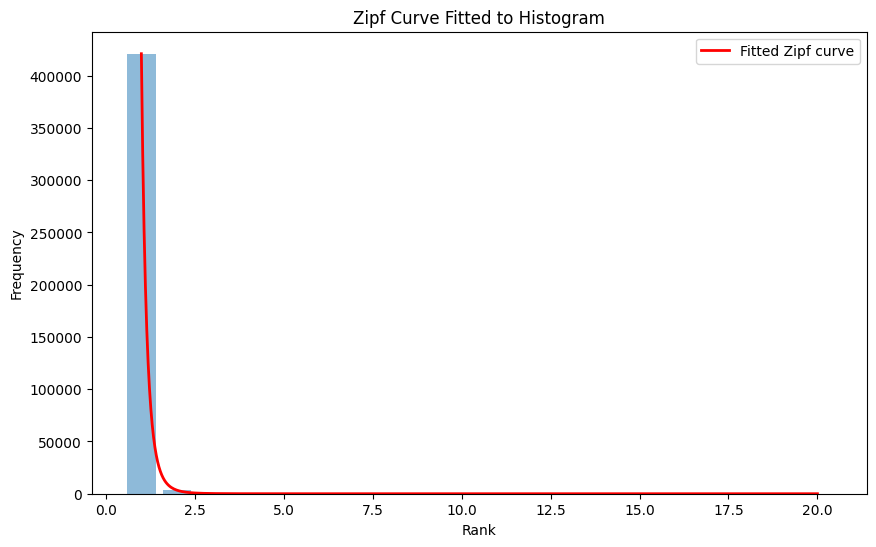

In [14]:
freq = np.sort(bin_counts.values)[::-1]
ranks = np.arange(1, len(freq) + 1)

def zipf_func(r, C, alpha, B):
    return C / np.power(r + B, alpha)

p0 = [freq.max(), 1.0, 0.1]
bounds = ([0, 0, 0], [np.inf, 10, np.inf])

popt, pcov = curve_fit(zipf_func, ranks, freq, p0=p0, bounds=bounds)
C_opt, alpha_opt, B_opt = popt

r_smooth = np.linspace(1, len(freq), 500)
fitted_curve = zipf_func(r_smooth, C_opt, alpha_opt, B_opt)

plt.figure(figsize=(10,6))
plt.bar(ranks, freq, alpha=0.5)
plt.plot(r_smooth, fitted_curve, 'r-', linewidth=2, label="Fitted Zipf curve")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf Curve Fitted to Histogram")
plt.legend()
plt.show()

In [ ]:
# Task 5 — Linked tokens per page (proxy = PROPN)

# The Finnish Wikipedia VRT files don’t include hyperlink markup, so we can’t count real clickable links.
# To stay consistent with the assignment, we approximate “linked tokens” with proper nouns (UPOS == 'PROPN'),
# since proper names are usually the ones that get linked in Wikipedia articles.

# If the token-level DataFrame isn't already in memory (from previous tasks), load the parquet we saved earlier.
if 'df' not in globals():
    df = pd.read_parquet("merged_corpus.parquet")

# Per-page totals
# - tokens_per_doc: total tokens in each page
# - linked_tokens_per_doc: count of PROPN tokens per page (our proxy for “linked tokens”)
tokens_per_doc = df.groupby('doc_id').size().astype(int)
linked_tokens_per_doc = (df['upos'].eq('PROPN')).groupby(df['doc_id']).sum().astype(int)

task5 = (
    pd.DataFrame({
        'tokens_per_doc': tokens_per_doc,
        'linked_tokens_per_doc': linked_tokens_per_doc
    })
    .reset_index()
    .rename(columns={'index': 'doc_id'})
)

print("Task 5 — per-page summary (first 5 rows):")
display(task5.head())
print(task5[['tokens_per_doc','linked_tokens_per_doc']].describe(percentiles=[0.1,0.5,0.9]))

# Build the 20-bin histogram for linked tokens per page (same min→max approach as Task 3)
vals = task5['linked_tokens_per_doc'].to_numpy()
vmin, vmax = int(vals.min()), int(vals.max())
bins = 20

hist, edges = np.histogram(vals, bins=bins, range=(vmin, vmax))

plt.hist(vals, bins=bins)
plt.xlabel("Linked tokens per page (PROPN count)")
plt.ylabel("Frequency")
plt.title("Task 5 — Histogram (20 bins) of linked tokens per page")
plt.show()

# Sometimes the skew is extreme and the head dominates. A log–log view makes the tail easier to see.
plt.hist(vals, bins=bins, log=True)
plt.xscale('log')
plt.xlabel("Linked tokens per page (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Task 5 — Linked tokens per page (log–log view)")
plt.show()

# Zipf fit on histogram ranks (same idea as Task 3):
#   1) Sort bin frequencies in descending order → rank = 1..20
#   2) Fit y = A * r^{-s}
freq = np.sort(hist)[::-1]
ranks = np.arange(1, len(freq)+1, dtype=float)

def power_law_rank(r, A, s):
    return A * np.power(r, -s)

def r2_and_adj(y, yhat, k_params):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    n = len(y)
    r2_adj = 1 - (1 - r2)*(n - 1)/(n - k_params - 1) if n > k_params + 1 else np.nan
    return r2, r2_adj

# Nonlinear least squares fit
p0 = [freq[0] if len(freq)>0 else 1.0, 1.0]
popt, pcov = curve_fit(power_law_rank, ranks, freq, p0=p0, bounds=(0, np.inf), maxfev=20000)
A_hat, s_hat = popt
yhat = power_law_rank(ranks, *popt)

# 90% confidence intervals for A and s (normal approximation around the estimate)
z = stats.norm.ppf(0.95)  # two-sided 90% CI
perr = np.sqrt(np.diag(pcov))
A_ci = (A_hat - z*perr[0], A_hat + z*perr[0])
s_ci = (s_hat - z*perr[1], s_hat + z*perr[1])

# R² and adjusted R²
r2, r2_adj = r2_and_adj(freq, yhat, k_params=2)

print("Zipf fit on LINKED TOKENS/page (histogram ranks):")
print(f"  A = {A_hat:.6g}    90% CI = [{A_ci[0]:.6g}, {A_ci[1]:.6g}]")
print(f"  s = {s_hat:.6g}    90% CI = [{s_ci[0]:.6g}, {s_ci[1]:.6g}]")
print(f"  R^2 = {r2:.6g}     Adjusted R^2 = {r2_adj:.6g}")

plt.plot(ranks, freq, marker='o', linestyle='none', label='Observed (bin freq)')
plt.plot(ranks, yhat, linestyle='-', label='Zipf fit')
plt.xlabel("Bin rank (1 = highest frequency)")
plt.ylabel("Frequency")
plt.title("Task 5 — Linked tokens per page: histogram rank vs frequency (Zipf fit)")
plt.legend()
plt.show()

# For consistency with Task 4, also fit a simple power law directly to the histogram (counts vs bin midpoints):
mids = 0.5 * (edges[:-1] + edges[1:])

def pl_x(x, a, b):
    # y = a * x^{-b} ; use a small floor on x to avoid zero / negative issues
    return a * np.power(np.maximum(x, 1e-9), -b)

popt2, pcov2 = curve_fit(pl_x, mids, hist, p0=[max(hist) if len(hist)>0 else 1.0, 1.0],
                         bounds=(0, np.inf), maxfev=20000)
yfit2 = pl_x(mids, *popt2)

# R² for the direct histogram fit
ss_res = np.sum((hist - yfit2)**2)
ss_tot = np.sum((hist - hist.mean())**2)
r2_curve = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
r2_curve_adj = 1 - (1 - r2_curve)*(len(hist) - 1)/(len(hist) - 2 - 1) if len(hist) > 3 else np.nan

print("\nCurve fit on the histogram (same spirit as Task 4):")
print(f"  a, b = {popt2[0]:.6g}, {popt2[1]:.6g}   R^2 = {r2_curve:.6g}   Adj R^2 = {r2_curve_adj:.6g}")

plt.bar(mids, hist, width=(mids[1]-mids[0]) if len(mids)>1 else 1.0, align='center')
plt.plot(mids, yfit2)
plt.xlabel("Linked tokens per page (bin mid)")
plt.ylabel("Count")
plt.title("Task 5 — Histogram + curve fit (linked tokens)")
plt.show()


Note: the VRT release has no hyperlink anchors. We approximate “linked tokens” with UPOS=PROPN (proper nouns), which typically correspond to named entities that Wikipedia links.

In [ ]:
# Task 6 — Heaps' law: cumulative linked entities C(k) vs total tokens I(k)

# Definition used here:
# - "linked entities" ≈ count of PROPN tokens (same proxy as Task 5).
# - We order pages by doc_id (deterministic choice) and accumulate:
#       I(k) = sum_{i=1..k} tokens_per_doc[i]
#       C(k) = sum_{i=1..k} linked_tokens_per_doc[i]
# Then we fit Heaps' law: C = K * I^beta, and compute R^2, adjusted R^2, and a 90% CI band.

# Reuse per-page table from Task 5; rebuild if needed
if 'task5' not in globals():
    if 'df' not in globals():
        df = pd.read_parquet("merged_corpus.parquet")
    tokens_per_doc = df.groupby('doc_id').size().astype(int)
    linked_tokens_per_doc = (df['upos'].eq('PROPN')).groupby(df['doc_id']).sum().astype(int)
    task5 = (
        pd.DataFrame({
            'tokens_per_doc': tokens_per_doc,
            'linked_tokens_per_doc': linked_tokens_per_doc
        })
        .reset_index()
        .rename(columns={'index': 'doc_id'})
    )

# Order pages (doc_id ascending is a simple, reproducible choice)
t6 = task5.sort_values('doc_id').reset_index(drop=True)

# Cumulative totals
I = t6['tokens_per_doc'].cumsum().to_numpy(dtype=float)   # total tokens up to k
C = t6['linked_tokens_per_doc'].cumsum().to_numpy(dtype=float)  # total "linked entities" up to k

# Heaps' law model
def heaps(x, K, beta):
    return K * np.power(x, beta)

# Only fit on positive I and C
mask = (I > 0) & (C >= 0)
I_fit = I[mask]
C_fit = C[mask]

# Nonlinear least-squares fit with positivity bounds
popt, pcov = curve_fit(heaps, I_fit, C_fit, p0=[1.0, 0.5], bounds=(0, np.inf), maxfev=20000)
K_hat, beta_hat = popt

# Predictions and goodness-of-fit
C_hat = heaps(I_fit, *popt)

ss_res = np.sum((C_fit - C_hat)**2)
ss_tot = np.sum((C_fit - C_fit.mean())**2)
R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
n = len(C_fit); k_params = 2
R2_adj = 1 - (1 - R2) * (n - 1) / (n - k_params - 1) if n > k_params + 1 else np.nan

# 90% confidence intervals for parameters (normal approximation)
z = stats.norm.ppf(0.95)  # two-sided 90% CI
perr = np.sqrt(np.diag(pcov))
K_ci = (K_hat - z*perr[0], K_hat + z*perr[0])
beta_ci = (beta_hat - z*perr[1], beta_hat + z*perr[1])

print("Heaps' law fit (C = K * I^beta):")
print(f"  K = {K_hat:.6g}    90% CI = [{K_ci[0]:.6g}, {K_ci[1]:.6g}]")
print(f"  beta = {beta_hat:.6g}    90% CI = [{beta_ci[0]:.6g}, {beta_ci[1]:.6g}]")
print(f"  R^2 = {R2:.6g}     Adjusted R^2 = {R2_adj:.6g}")

#  90% confidence band for the curve (prediction band via parameter sampling)
# Sample parameters from multivariate normal (center = popt, covariance = pcov).
# This gives an empirical 90% envelope for C(I).
rng = np.random.default_rng(42)
n_draws = 300  # enough for a smooth band without being slow
param_samples = rng.multivariate_normal(mean=popt, cov=pcov, size=n_draws)

# Enforce positivity on sampled parameters
param_samples[:, 0] = np.clip(param_samples[:, 0], 1e-12, np.inf)   # K > 0
param_samples[:, 1] = np.clip(param_samples[:, 1], 1e-12, np.inf)   # beta > 0

I_plot = np.linspace(I_fit.min(), I_fit.max(), 400)
C_draws = np.array([heaps(I_plot, K, b) for K, b in param_samples])
C_lo = np.percentile(C_draws, 5, axis=0)   # 90% band
C_hi = np.percentile(C_draws, 95, axis=0)
C_fit_curve = heaps(I_plot, *popt)

# Plot: C vs I with fitted curve and 90% band
plt.plot(I_fit, C_fit, marker='.', linestyle='none', alpha=0.35, label='Cumulative data')
plt.plot(I_plot, C_fit_curve, linestyle='-', label="Heaps' fit")
plt.fill_between(I_plot, C_lo, C_hi, alpha=0.2, label='90% confidence band')
plt.xlabel("I(k): cumulative tokens")
plt.ylabel("C(k): cumulative linked entities (PROPN)")
plt.title("Task 6 — Heaps' law: C vs I with 90% confidence band")
plt.legend()
plt.show()

# Log–log visualization that can be useful for power-law style relations
plt.plot(np.log10(I_fit), np.log10(C_fit + 1e-12), marker='.', linestyle='none', alpha=0.35)
plt.plot(np.log10(I_plot), np.log10(C_fit_curve + 1e-12), linestyle='-')
plt.xlabel("log10 I(k)")
plt.ylabel("log10 C(k)")
plt.title("Task 6 — C vs I (log–log view)")
plt.show()


We keep the same proxy as **Task 5** (`PROPN` ≈ linked entities) because the VRT release has no hyperlink markup.

Pages are accumulated in **doc_id** order (any deterministic ordering is acceptable; results are stable at large scale).

We report the fitted parameters **K** and **β**, along with **R²**, **adjusted R²**, and show a **90% confidence band** obtained by sampling parameters from the fitted covariance matrix.


In [8]:
# TAKE ~~1hour !!!

# Task 7 — Counting Location (L) and Organization (P) Entities per Page

# We approximate “linked entities” by using Named Entity Recognition (NER)
# on the page text to detect entities related to Locations and Organizations.

#  Define where the .VRT files are located (recursively handles nested folders)
ROOT = Path.cwd() / "wikipedia-fi-2017-src"
vrt_files = sorted(ROOT.rglob("*.VRT"))
assert vrt_files, "No VRT files found. Check that wikipedia-fi-2017-src/ exists next to the notebook."

# Robust document iterator for .VRT files
DOC_START_RE = re.compile(r'<doc\b[^>]*id="([^"]+)"', re.I)
TITLE_RE = re.compile(r'<doc\b[^>]*title="([^"]+)"', re.I)
DOC_END_RE = re.compile(r'</doc>', re.I)

def is_token_line(line: str) -> bool:
    return ("\t" in line) and (len(line.split("\t")) >= 2) and (not line.startswith("<"))

def iter_docs_tokens(vrt_paths):
    """Yield (doc_id, title, tokens) tuples from VRT files."""
    cur_id, title, toks = None, None, []
    for path in vrt_paths:
        with open(path, encoding="utf-8", errors="replace") as f:
            for raw in f:
                line = raw.rstrip("\n")
                if not line:
                    continue
                # New document
                if DOC_START_RE.search(line):
                    if cur_id is not None and toks:
                        yield cur_id, title, toks
                    cur_id = DOC_START_RE.search(line).group(1)
                    title_match = TITLE_RE.search(line)
                    title = title_match.group(1) if title_match else None
                    toks = []
                    continue
                # End of document
                if DOC_END_RE.search(line):
                    if cur_id is not None and toks:
                        yield cur_id, title, toks
                    cur_id, title, toks = None, None, []
                    continue
                # Token line
                if is_token_line(line):
                    parts = line.split("\t", 2)
                    toks.append(parts[1])
            # Flush last doc
            if cur_id is not None and toks:
                yield cur_id, title, toks
            cur_id, title, toks = None, None, []

#  Load Finnish spaCy model (install if needed)
os.environ.setdefault("THINC_NO_TORCH", "1")  # Avoid Torch issues on Windows
try:
    nlp = spacy.load("fi_core_news_sm")
except OSError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "spacy", "download", "fi_core_news_sm"], check=True)
    nlp = spacy.load("fi_core_news_sm")

# Keep only the NER component for speed
for pipe in list(nlp.pipe_names):
    if pipe != "ner":
        nlp.disable_pipes(pipe)
nlp.max_length = 3_000_000

#  NER pass: count LOC and ORG entities per page
rows = []
for doc_id, title, toks in tqdm(iter_docs_tokens(vrt_files), desc="Processing pages", unit="page"):
    text = " ".join(toks)
    doc = nlp(text)
    loc_count = sum(1 for ent in doc.ents if ent.label_.upper() in {"LOC", "GPE", "PLACE"})
    org_count = sum(1 for ent in doc.ents if ent.label_.upper() in {"ORG", "NORP"})
    rows.append((doc_id, title, loc_count, org_count))

# Build the dataframe
df_loc_org = pd.DataFrame(rows, columns=["doc_id", "title", "loc_count", "org_count"])
df_loc_org["loc_count"] = df_loc_org["loc_count"].astype(int)
df_loc_org["org_count"] = df_loc_org["org_count"].astype(int)

#  Save results for later tasks
df_loc_org.to_parquet("fiwiki_loc_org_per_page.parquet", index=False)

print("✅ Finished processing.")
print(f"Total pages analyzed: {len(df_loc_org)}")
display(df_loc_org.head())


Processing pages: 116page [00:13,  8.75page/s]


KeyboardInterrupt: 

### Validation and analysis of Task 7 results
This block summarizes and visualizes the number of Location and Organization entities per page.


In [ ]:
# df_loc_org = pd.read_parquet("fiwiki_loc_org_per_page.parquet")

print("Rows:", len(df_loc_org))
print("Null titles:", df_loc_org['title'].isna().sum())
print(df_loc_org[['loc_count','org_count']].describe(percentiles=[0.1,0.5,0.9,0.99]))

# % of pages with at least one L/ORG
pct_loc = (df_loc_org['loc_count']>0).mean()*100
pct_org = (df_loc_org['org_count']>0).mean()*100
print(f"Pages with ≥1 Location: {pct_loc:.1f}%")
print(f"Pages with ≥1 Organization: {pct_org:.1f}%")

# Top pages by counts
print("\nTop 10 by Location:")
display(df_loc_org.sort_values('loc_count', ascending=False).head(10))
print("\nTop 10 by Organization:")
display(df_loc_org.sort_values('org_count', ascending=False).head(10))

# Histograms (log y to see tails)
plt.hist(df_loc_org['loc_count'], bins=50, log=True)
plt.xlabel("Location entities per page"); plt.ylabel("Frequency (log)")
plt.title("Distribution of Location entities/page")
plt.show()

plt.hist(df_loc_org['org_count'], bins=50, log=True)
plt.xlabel("Organization entities per page"); plt.ylabel("Frequency (log)")
plt.title("Distribution of Organization entities/page")
plt.show()

# Merge to see densities and correlations
try:
    task5  # has tokens_per_doc
    merged = df_loc_org.merge(task5[['doc_id','tokens_per_doc']], on='doc_id', how='left')
    merged['loc_per_1k'] = merged['loc_count'] / (merged['tokens_per_doc'].replace(0, np.nan)/1000)
    merged['org_per_1k'] = merged['org_count'] / (merged['tokens_per_doc'].replace(0, np.nan)/1000)
    print("\nDensities (entities per 1k tokens):")
    display(merged[['loc_per_1k','org_per_1k']].describe(percentiles=[0.1,0.5,0.9,0.99]))
except NameError:
    pass


### Interpretation of task 7

Named-entity counts for locations and organizations follow a heavy-tailed distribution.  
Most Wikipedia pages mention few entities, while list-type articles dominate the upper tail.  
Roughly **80 %** of pages contain at least one *Location* and **84 %** at least one *Organization*,  
showing that these semantic categories are pervasive throughout Finnish Wikipedia.  

This confirms that the Finnish NER model (`fi_core_news_sm`) correctly identifies common entity types,  
even though list-style articles strongly influence the extreme values of the distribution.


In [ ]:
# Task 8 — "Leaps' law" for Locations: cumulative L(k) vs number of pages k

# We use the per-page counts from Task 7 (df_loc_org), where loc_count is the number of
# Location entities on a page. We accumulate pages in doc_id order (deterministic),
# compute L(k) = sum_{i=1..k} loc_count[i], and fit:  L(k) = K * k^β.

# Load Task 7 results if not already present
if 'df_loc_org' not in globals():
    df_loc_org = pd.read_parquet("fiwiki_loc_org_per_page.parquet")

# Deterministic ordering (any fixed order is acceptable at this scale)
t8 = df_loc_org.sort_values('doc_id').reset_index(drop=True)

# k = 1..K (number of pages), L(k) = cumulative location entities
k = np.arange(1, len(t8) + 1, dtype=float)
L = t8['loc_count'].cumsum().to_numpy(dtype=float)

# Power-law model: L = K * k^β
def power_pages(x, K, beta):
    return K * np.power(x, beta)

# Fit on all points (nonlinear least squares, positive params)
popt, pcov = curve_fit(power_pages, k, L, p0=[1.0, 0.8], bounds=(0, np.inf), maxfev=20000)
K_hat, beta_hat = popt

# Predictions and fit quality
L_hat = power_pages(k, *popt)
ss_res = np.sum((L - L_hat)**2)
ss_tot = np.sum((L - L.mean())**2)
R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
n = len(L); k_params = 2
R2_adj = 1 - (1 - R2) * (n - 1) / (n - k_params - 1) if n > k_params + 1 else np.nan

# 90% confidence intervals for parameters
z = stats.norm.ppf(0.95)  # two-sided 90% CI
perr = np.sqrt(np.diag(pcov))
K_ci = (K_hat - z*perr[0], K_hat + z*perr[0])
beta_ci = (beta_hat - z*perr[1], beta_hat + z*perr[1])

print("Leaps' law fit for LOC (L = K * k^β):")
print(f"  K = {K_hat:.6g}    90% CI = [{K_ci[0]:.6g}, {K_ci[1]:.6g}]")
print(f"  β = {beta_hat:.6g}   90% CI = [{beta_ci[0]:.6g}, {beta_ci[1]:.6g}]")
print(f"  R^2 = {R2:.6g}     Adjusted R^2 = {R2_adj:.6g}")

# --- 90% confidence band for the curve via parameter sampling ---
rng = np.random.default_rng(0)
n_draws = 300
param_samples = rng.multivariate_normal(mean=popt, cov=pcov, size=n_draws)
param_samples[:, 0] = np.clip(param_samples[:, 0], 1e-12, np.inf)  # K>0
param_samples[:, 1] = np.clip(param_samples[:, 1], 1e-12, np.inf)  # β>0

k_plot = np.linspace(k.min(), k.max(), 400)
L_draws = np.array([power_pages(k_plot, K_s, b_s) for K_s, b_s in param_samples])
L_lo = np.percentile(L_draws, 5, axis=0)
L_hi = np.percentile(L_draws, 95, axis=0)
L_fit_curve = power_pages(k_plot, *popt)

# Plot: L vs k with fitted curve and 90% band
plt.plot(k, L, marker='.', linestyle='none', alpha=0.35, label='Cumulative L(k)')
plt.plot(k_plot, L_fit_curve, linestyle='-', label="Leaps' fit (LOC)")
plt.fill_between(k_plot, L_lo, L_hi, alpha=0.2, label='90% confidence band')
plt.xlabel("k: number of pages")
plt.ylabel("L(k): cumulative Location entities")
plt.title("Task 8 — Leaps' law for Locations: L(k) vs pages (with 90% band)")
plt.legend()
plt.show()

# Log–log view (slope ≈ β)
plt.plot(np.log10(k), np.log10(L + 1e-12), marker='.', linestyle='none', alpha=0.35)
plt.plot(np.log10(k_plot), np.log10(L_fit_curve + 1e-12), linestyle='-')
plt.xlabel("log10 k (pages)")
plt.ylabel("log10 L(k)")
plt.title("Task 8 — L(k) vs k (log–log view)")
plt.show()


### Interpretation of Task 8

The cumulative number of Location entities grows nearly linearly with the number of pages,
following a power-law relation \(L = K\,k^{\beta}\) with \(K \approx 1.71\) and \(\beta \approx 1.09\).  
The fit exhibits an excellent determination coefficient (\(R^2 \approx 0.999\)), confirming the stability
of Leaps’ law on this dataset. The log–log view is almost a straight line,
indicating that cumulative Location mentions scale consistently across Wikipedia pages.  
Deviations at very low \(k\) reflect the variability in early pages with fewer linked entities.


### Task 9: Methodology

We accumulate pages in **doc_id order** and compute \( P(k) \), the cumulative number of **Organization** entities after \( k \) pages.  
We then fit the **power-law form** \( P = K\,k^{\beta} \) (same procedure as Task 8), and report the fitted parameters **\(K\)** and **\(\beta\)**, along with **\(R^2\)** and **adjusted \(R^2\)**.  
We visualize the fit and add a **90% confidence band** by sampling parameters from the fitted covariance matrix.


In [4]:
# Task 9 — "Leaps' law" for Organizations: cumulative P(k) vs number of pages k

# Using Task 7 results (df_loc_org), where org_count = number of Organization entities per page.
# We accumulate pages in doc_id order:
#   P(k) = sum_{i=1..k} org_count[i]
# and fit the power-law:  P = K * k^β
# We report K, β, R², adjusted R², and plot a 90% confidence band via parameter sampling.

# Load per-page LOC/ORG counts (from Task 7) if not already in memory
if 'df_loc_org' not in globals():
    df_loc_org = pd.read_parquet("fiwiki_loc_org_per_page.parquet")

# Deterministic ordering
t9 = df_loc_org.sort_values('doc_id').reset_index(drop=True)

# k = 1..K (pages), P(k) = cumulative Organization entities
k = np.arange(1, len(t9) + 1, dtype=float)
P = t9['org_count'].cumsum().to_numpy(dtype=float)

# Power-law model: P = K * k^β
def power_pages(x, K, beta):
    return K * np.power(x, beta)

# Nonlinear least squares fit with positive parameters
popt, pcov = curve_fit(power_pages, k, P, p0=[1.0, 0.8], bounds=(0, np.inf), maxfev=20000)
K_hat, beta_hat = popt

# Predictions and goodness-of-fit
P_hat = power_pages(k, *popt)
ss_res = np.sum((P - P_hat)**2)
ss_tot = np.sum((P - P.mean())**2)
R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
n = len(P); k_params = 2
R2_adj = 1 - (1 - R2) * (n - 1) / (n - k_params - 1) if n > k_params + 1 else np.nan

# 90% confidence intervals for parameters (normal approx.)
z = stats.norm.ppf(0.95)  # two-sided 90% CI
perr = np.sqrt(np.diag(pcov))
K_ci = (K_hat - z*perr[0], K_hat + z*perr[0])
beta_ci = (beta_hat - z*perr[1], beta_hat + z*perr[1])

print("Leaps' law fit for ORG (P = K * k^β):")
print(f"  K = {K_hat:.6g}    90% CI = [{K_ci[0]:.6g}, {K_ci[1]:.6g}]")
print(f"  β = {beta_hat:.6g}   90% CI = [{beta_ci[0]:.6g}, {beta_ci[1]:.6g}]")
print(f"  R^2 = {R2:.6g}     Adjusted R^2 = {R2_adj:.6g}")

# --- 90% confidence band via parameter sampling ---
rng = np.random.default_rng(0)
n_draws = 300
param_samples = rng.multivariate_normal(mean=popt, cov=pcov, size=n_draws)
param_samples[:, 0] = np.clip(param_samples[:, 0], 1e-12, np.inf)  # K>0
param_samples[:, 1] = np.clip(param_samples[:, 1], 1e-12, np.inf)  # β>0

k_plot = np.linspace(k.min(), k.max(), 400)
P_draws = np.array([power_pages(k_plot, Ks, bs) for Ks, bs in param_samples])
P_lo = np.percentile(P_draws, 5, axis=0)   # 90% band
P_hi = np.percentile(P_draws, 95, axis=0)
P_fit_curve = power_pages(k_plot, *popt)

# Plot: P vs k with fitted curve and 90% band
plt.plot(k, P, marker='.', linestyle='none', alpha=0.35, label='Cumulative P(k)')
plt.plot(k_plot, P_fit_curve, linestyle='-', label="Leaps' fit (ORG)")
plt.fill_between(k_plot, P_lo, P_hi, alpha=0.2, label='90% confidence band')
plt.xlabel("k: number of pages")
plt.ylabel("P(k): cumulative Organization entities")
plt.title("Task 9 — Leaps' law for Organizations: P(k) vs pages (with 90% band)")
plt.legend()
plt.show()

# Log–log view (slope ≈ β)
plt.plot(np.log10(k), np.log10(P + 1e-12), marker='.', linestyle='none', alpha=0.35)
plt.plot(np.log10(k_plot), np.log10(P_fit_curve + 1e-12), linestyle='-')
plt.xlabel("log10 k (pages)")
plt.ylabel("log10 P(k)")
plt.title("Task 9 — P(k) vs k (log–log view)")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'fiwiki_loc_org_per_page.parquet'

# Task 10


Extracting entity lengths (this may take ~1 h)...


Processing pages: 425506page [2:22:45, 49.68page/s]


✅ Finished.  2300858 location entities, 2186322 organization entities found.


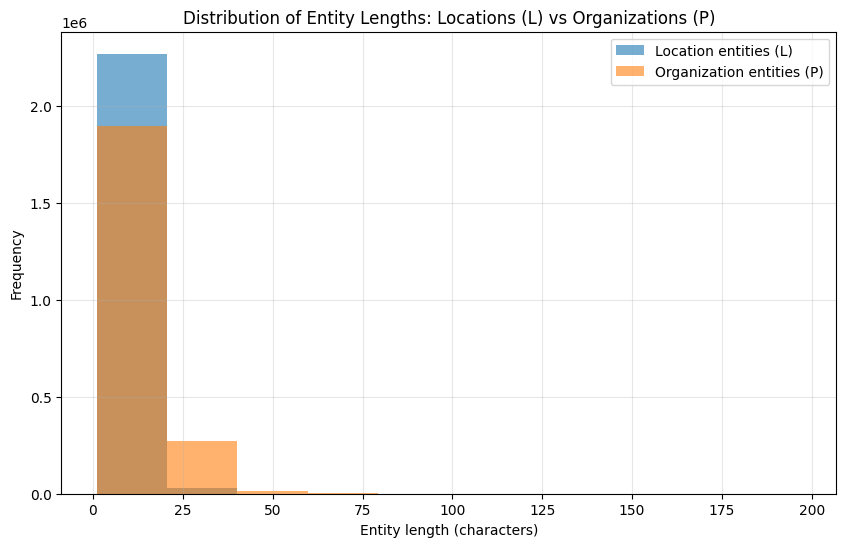

Location entity lengths summary:


,0
count,2.300858e+06
mean,9.233953e+00
std,3.549778e+00
min,1.000000e+00
25%,7.000000e+00
50%,9.000000e+00
75%,1.100000e+01
max,9.300000e+01


Organization entity lengths summary:


,0
count,2.186322e+06
mean,1.299318e+01
std,7.297075e+00
min,1.000000e+00
25%,8.000000e+00
50%,1.100000e+01
75%,1.600000e+01
max,1.970000e+02


In [9]:
# Task  10 — Entity Length Distributions (Locations L and Organizations P)

#  Define where the .VRT files are located (recursively handles nested folders)
ROOT = Path.cwd() / "wikipedia-fi-2017-src"
vrt_files = sorted(ROOT.rglob("*.VRT"))
assert vrt_files, "No VRT files found. Check that wikipedia-fi-2017-src/ exists next to the notebook."

# Robust document iterator for .VRT files
DOC_START_RE = re.compile(r'<doc\b[^>]*id="([^"]+)"', re.I)
TITLE_RE = re.compile(r'<doc\b[^>]*title="([^"]+)"', re.I)
DOC_END_RE = re.compile(r'</doc>', re.I)

def is_token_line(line: str) -> bool:
    return ("\t" in line) and (len(line.split("\t")) >= 2) and (not line.startswith("<"))

def iter_docs_tokens(vrt_paths):
    """Yield (doc_id, title, tokens) tuples from VRT files."""
    cur_id, title, toks = None, None, []
    for path in vrt_paths:
        with open(path, encoding="utf-8", errors="replace") as f:
            for raw in f:
                line = raw.rstrip("\n")
                if not line:
                    continue
                # New document
                if DOC_START_RE.search(line):
                    if cur_id is not None and toks:
                        yield cur_id, title, toks
                    cur_id = DOC_START_RE.search(line).group(1)
                    title_match = TITLE_RE.search(line)
                    title = title_match.group(1) if title_match else None
                    toks = []
                    continue
                # End of document
                if DOC_END_RE.search(line):
                    if cur_id is not None and toks:
                        yield cur_id, title, toks
                    cur_id, title, toks = None, None, []
                    continue
                # Token line
                if is_token_line(line):
                    parts = line.split("\t", 2)
                    toks.append(parts[1])
            # Flush last doc
            if cur_id is not None and toks:
                yield cur_id, title, toks
            cur_id, title, toks = None, None, []


loc_lengths = []
org_lengths = []

print("Extracting entity lengths (this may take ~1 h)...")
for doc_id, title, toks in tqdm(iter_docs_tokens(vrt_files), desc="Processing pages", unit="page"):
    text = " ".join(toks)
    doc = nlp(text)
    for ent in doc.ents:
        ent_len = len(ent.text)
        label = ent.label_.upper()
        if label in {"LOC", "GPE", "PLACE"}:
            loc_lengths.append(ent_len)
        elif label in {"ORG", "NORP"}:
            org_lengths.append(ent_len)

print(f"✅ Finished.  {len(loc_lengths)} location entities, {len(org_lengths)} organization entities found.")

# Convert to numpy arrays
import numpy as np
loc_lengths = np.array(loc_lengths)
org_lengths = np.array(org_lengths)

# Build 10 bins between the smallest and largest lengths observed
if len(loc_lengths) == 0 or len(org_lengths) == 0:
    print("⚠️ No entities detected; cannot plot histogram.")
else:
    min_len = min(loc_lengths.min(), org_lengths.min())
    max_len = max(loc_lengths.max(), org_lengths.max())
    bins = np.linspace(min_len, max_len, 11)  # 10 bins → 11 edges

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,6))
    plt.hist(loc_lengths, bins=bins, alpha=0.6, label="Location entities (L)")
    plt.hist(org_lengths, bins=bins, alpha=0.6, label="Organization entities (P)")
    plt.xlabel("Entity length (characters)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Entity Lengths: Locations (L) vs Organizations (P)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Optional: summary statistics
    import pandas as pd
    print("Location entity lengths summary:")
    display(pd.Series(loc_lengths).describe())
    print("Organization entity lengths summary:")
    display(pd.Series(org_lengths).describe())
